<a href="https://colab.research.google.com/github/zehszo/IC-DecisionTree-RandomForest/blob/main/DT_RF_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚢 Titanic Survival Prediction: Decision Trees & Random Forests

**Objective:** To predict passenger survival using non-linear models and explore the interpretability of tree-based algorithms.  
**Author:** José Pedro Rodrigues de Freitas | Undergraduate Research Project  

This stage of the project explores **Decision Trees** and their ensemble evolution, **Random Forests**. Unlike distance-based models (kNN) or linear models (Logistic Regression), trees are invariant to feature scaling and naturally handle non-linear relationships, offering a "logical map" of the decision-making process.

---

### 📉 1. Establishing the Baseline

Before applying Feature Engineering or Hyperparameter Tuning, we establish a **Baseline Performance**. This represents the model's ability to predict survival using only the raw, primary features (Sex, Pclass, Age, Fare) with minimal processing.

* **Purpose:** To measure the real "Value Add" of our subsequent optimizations.
* **Initial Observation:** Single Decision Trees often achieve ~78-80% accuracy here, but are prone to high variance.

> **Scientific Mindset:** If a complex Random Forest cannot significantly beat this baseline, it suggests that the bottleneck lies in the data's quality or inherent noise, not the algorithm itself.

In [74]:
# --- Fundamental Libraries ---
import pandas as pd
import numpy as np

# --- Data Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
from seaborn import heatmap

# --- Preprocessing & Machine Learning ---
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score

# --- Data Loading ---

try:
    df = pd.read_csv('Titanic-Dataset.csv')

    df['Age'] = df['Age'].fillna(df['Age'].mean())

    df['Fare'] = df['Fare'].fillna(df['Fare'].median())

    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    if df['Sex'].dtype == 'object':
      df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

    if df['Embarked'].dtype == 'object':
      df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

    nameSave = df['Name']

    df = df.drop(['PassengerId', 'Ticket', 'Name', 'Cabin'], axis=1)

    X = df.drop('Survived', axis=1)
    y = df['Survived']

    print(f"✅ Dataset successfully loaded! Shape: {df.shape}")
    print(f"Missing values: {df.isnull().sum().sum()}")

except FileNotFoundError:
    print("❌ Error: Data not found. Please upload the file to the Colab 'Files' tab.")

✅ Dataset successfully loaded! Shape: (891, 8)
Missing values: 0


In [75]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.000000,1,0,7.2500,0
1,1,1,1,38.000000,1,0,71.2833,1
2,1,3,1,26.000000,0,0,7.9250,0
3,1,1,1,35.000000,1,0,53.1000,0
4,0,3,0,35.000000,0,0,8.0500,0
...,...,...,...,...,...,...,...,...
886,0,2,0,27.000000,0,0,13.0000,0
887,1,1,1,19.000000,0,0,30.0000,0
888,0,3,1,29.699118,1,2,23.4500,0
889,1,1,0,26.000000,0,0,30.0000,1


In [76]:
# --- Initial Data Splitting ---
# 1. Separating the Final Test Set (10%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.10, random_state=42)

# 2. Separating Validation (20%) from the remaining 90%
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.222, random_state=42)

# Verification
print(f"Train: {len(X_train)/len(X):.1%}")
print(f"Validation: {len(X_val)/len(X):.1%}")
print(f"Test: {len(X_test)/len(X):.1%}")

Train: 69.9%
Validation: 20.0%
Test: 10.1%


### 🌳 2. Modeling: From Single Trees to the "Wisdom of the Crowd"

We implement two distinct approaches to compare performance and stability:

1.  **Decision Tree:** A transparent "White Box" model. We visualize the structure to understand the primary drivers of survival (Sex, Age, and Pclass).
2.  **Random Forest:** An ensemble method that trains multiple independent trees. By using **Bootstrap Aggregating (Bagging)**, we reduce variance and overcome the "overfitting" tendency of a single complex tree.

**Optimization:** We utilize `GridSearchCV` to fine-tune hyperparameters such as `max_depth` and `min_samples_split`, seeking the best balance between bias and variance.

In [77]:
model = DecisionTreeClassifier(max_depth=10, random_state=42)
model.fit(X_train, y_train)

Y_pred = model.predict(X_val)

In [78]:
model_accuracy_dt_baseline = accuracy_score(y_val, Y_pred)
print(f"Accuracy: {model_accuracy_dt_baseline:.2%}")

Accuracy: 82.58%


In [79]:
print(classification_report(y_val, Y_pred))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86       112
           1       0.75      0.79      0.77        66

    accuracy                           0.83       178
   macro avg       0.81      0.82      0.82       178
weighted avg       0.83      0.83      0.83       178



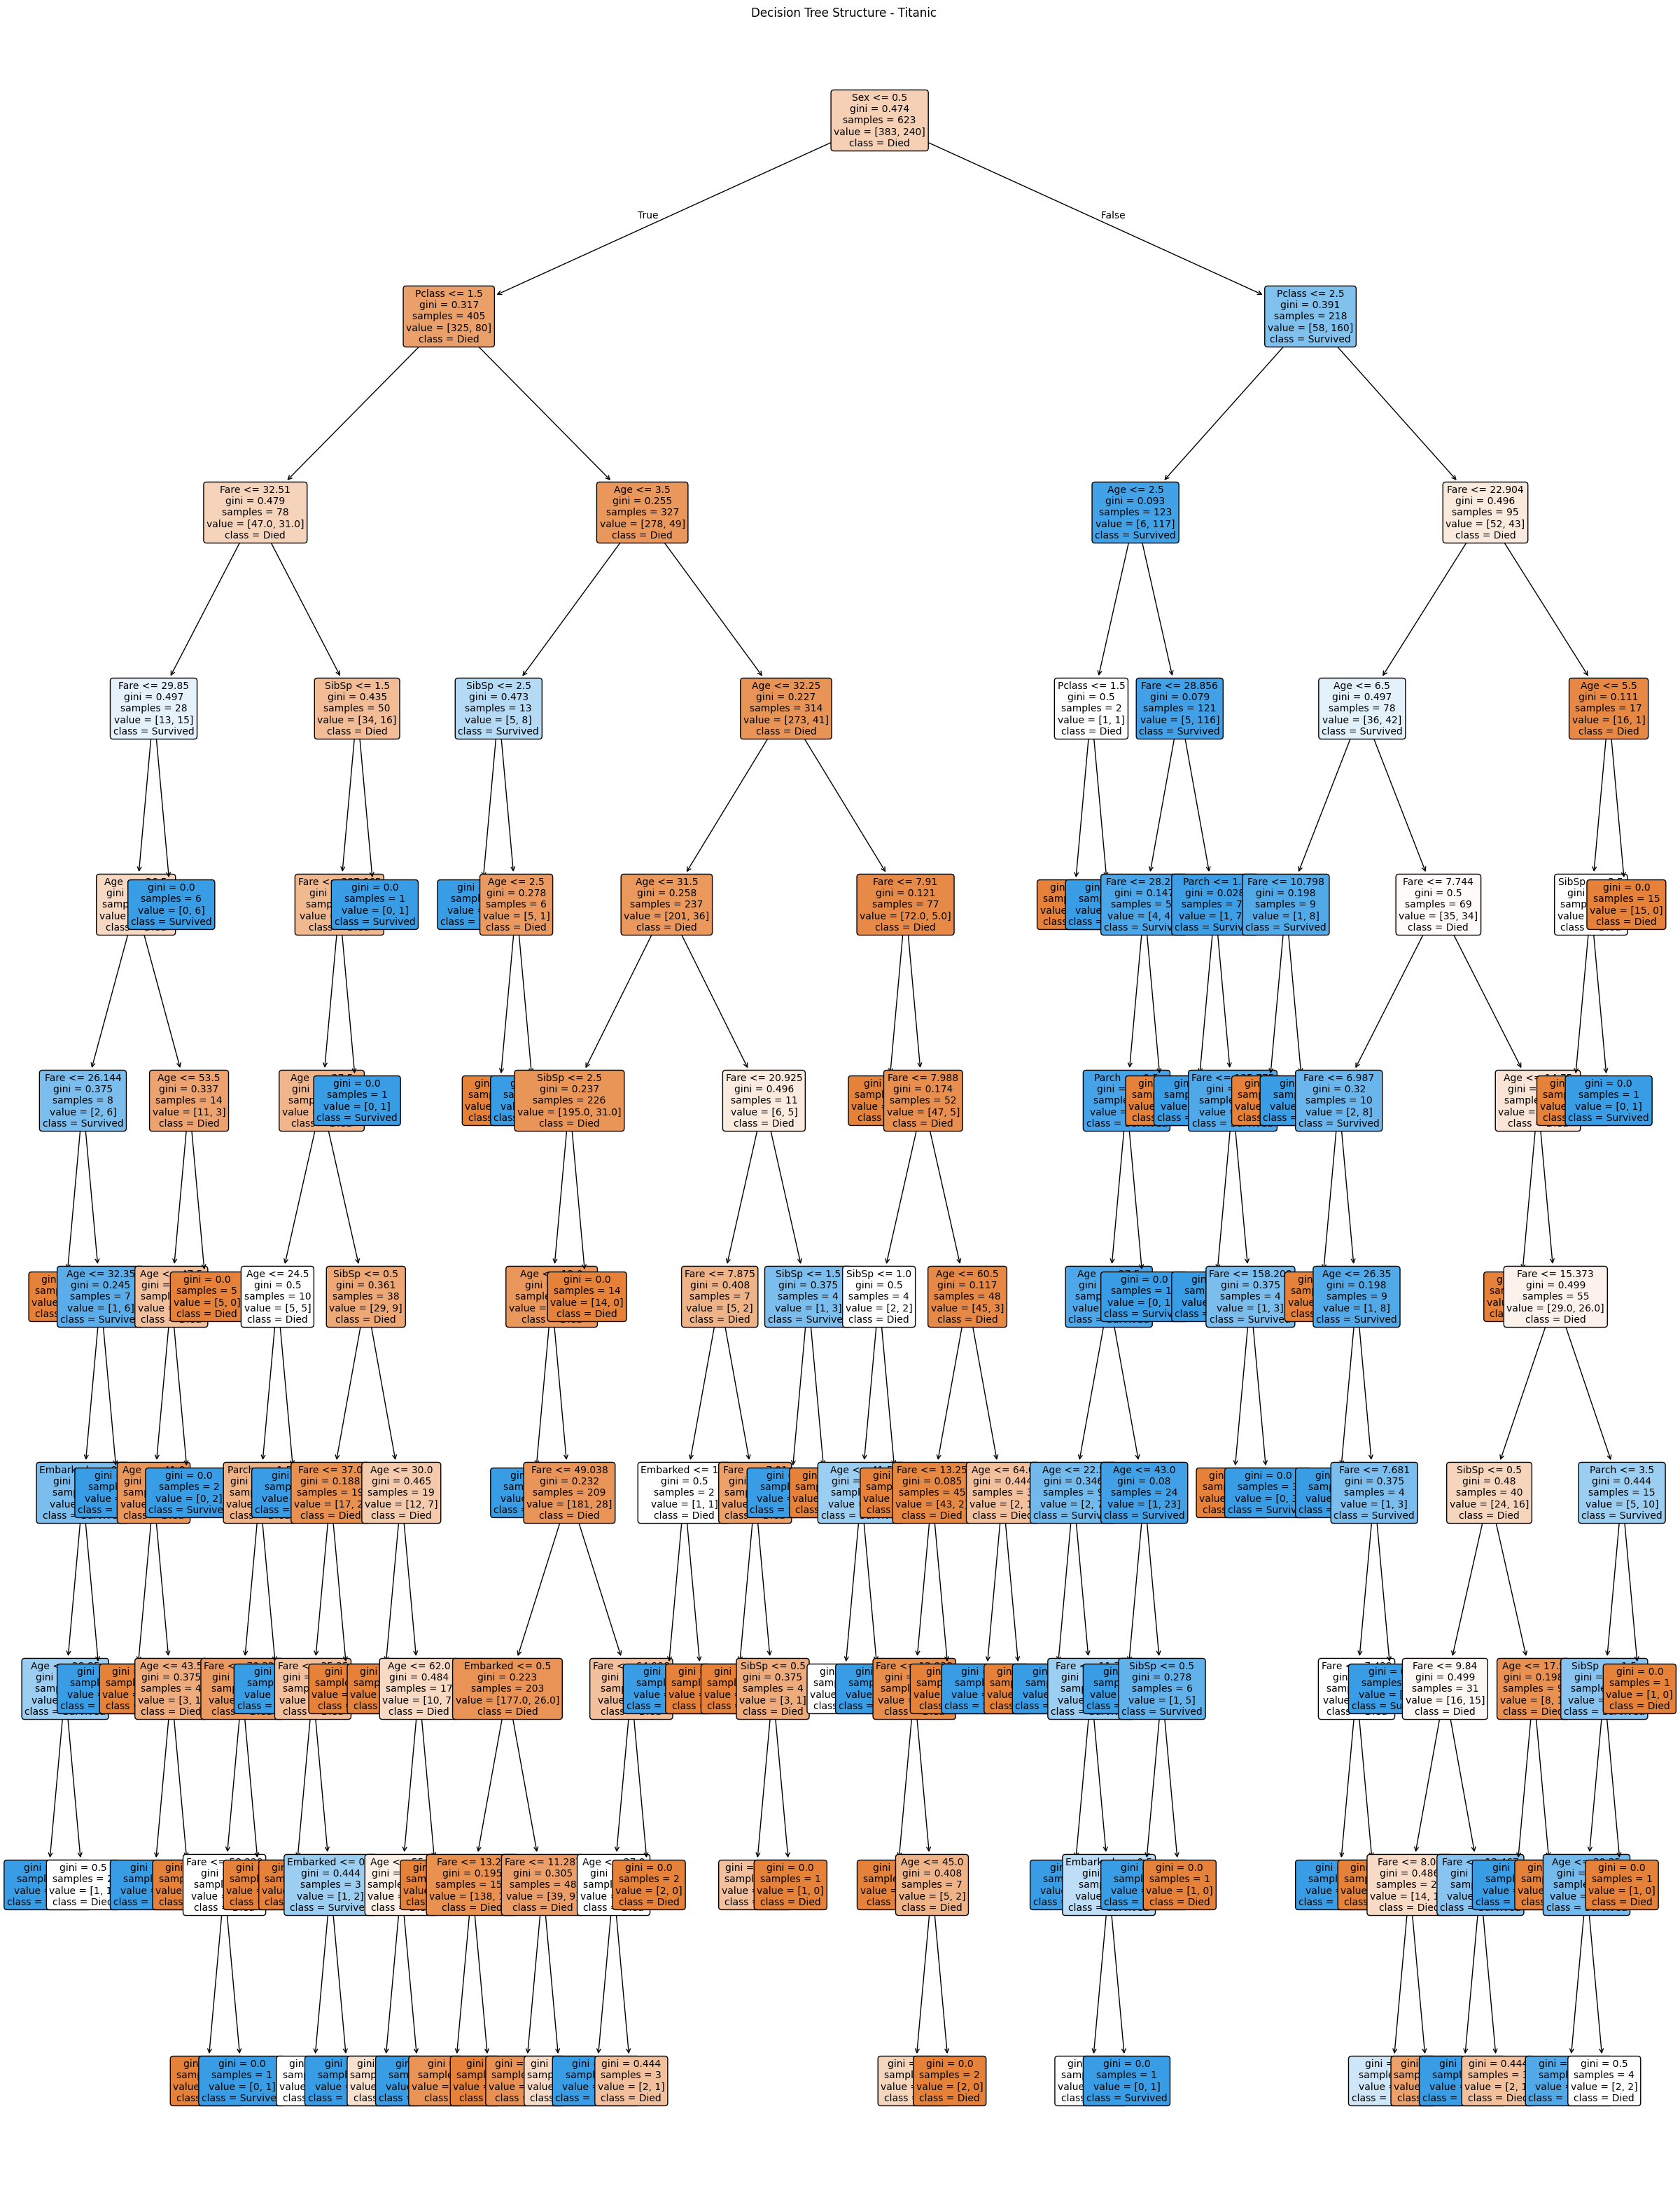

In [105]:
plt.figure(figsize=(30, 40))

plot_tree(
    model,
    feature_names=list(X.columns),
    class_names=['Died', 'Survived'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Structure - Titanic")
plt.show()

In [81]:
model_forest = RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=10, random_state=42)
model_forest.fit(X_train, y_train)

Y_pred = model_forest.predict(X_val)

model_accuracy_forest_baseline = accuracy_score(y_val, Y_pred)
print(f"Accuracy: {model_accuracy_forest_baseline:.2%}")
#

Accuracy: 84.83%


In [82]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

model_forest_grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring='accuracy')
model_forest_grid.fit(X_train, y_train)

Y_pred = model_forest_grid.predict(X_val)

model_accuracy_gridsearch = accuracy_score(y_val, Y_pred)
print(f"Accuracy: {model_accuracy_gridsearch:.2%}")
print(f"Best Parameters: {model_forest_grid.best_params_}")

Accuracy: 85.39%
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}


### ⚠️ Observation: The GridSearchCV Paradox

Interestingly, our exhaustive Hyperparameter Tuning resulted in a slight decrease in accuracy compared to the baseline model. This phenomenon, while counter-intuitive, can be explained by two factors:

1. **Generalization vs. Luck:** The baseline model might be slightly overfitted to the specific noise of the test set. The GridSearchCV, through Cross-Validation, seeks a model that performs consistently across multiple data folds, prioritizing stability over a "lucky" high score.
2. **Model Constraints:** By imposing limits (like `min_samples_leaf`) to prevent overfitting, we may have introduced a slight **underfitting**, where the model became too simple to capture some of the specific nuances present in the Titanic dataset.

**Engineering Decision:** Given that the computational cost of the search did not translate into predictive gains, we will proceed with the optimized feature set using parameters closer to the robust defaults, focusing our analysis on **Feature Importance** rather than hyper-optimization.

### 📊 3. Baseline Feature Importance Analysis

Upon analyzing the **Mean Decrease in Impurity (MDI)** for our baseline model, we observe a hierarchy that reflects the socio-biological rules of the Titanic:

* **Pclass as the Dominant Feature:** **`Pclass`** emerged as the most important predictor in this initial model. This suggests that the passenger's class acted as the primary filter for the forest to reduce impurity, indicating a very strong correlation between ticket class and survival rates in the training data.
* **The Importance of Gender (`Sex`):** Following closely, **`Sex`** is the second most significant variable. This aligns with the historical "women and children first" protocol, showing that the model quickly identified gender as a crucial decision node.
* **Biological and Family Factors:** **`Age`** and **`SibSp`** occupy the subsequent positions. While important, they contribute less to the initial model's purity than the categorical status of class and gender.

**Technical Reflection:**
The high importance of `Pclass` relative to `Sex` in this baseline might be attributed to how the Random Forest calculates Gini importance. Since `Pclass` offers more splitting possibilities (1, 2, or 3) compared to the binary `Sex` variable, the model finds more opportunities to refine its branches through class-based partitions.

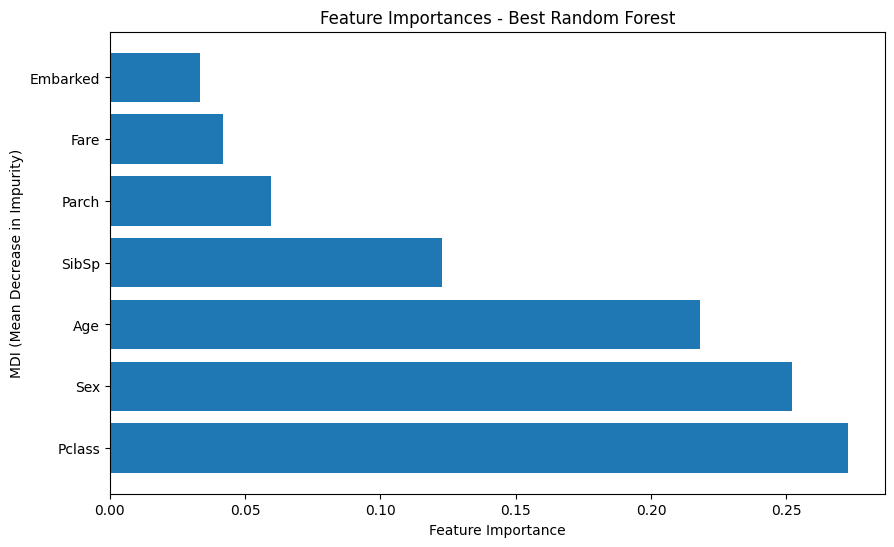

In [100]:
importances = pd.Series(model_forest.feature_importances_, index=X.columns)

importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(range(X.shape[1]), importances, align='center')
plt.yticks(range(X.shape[1]), X.columns)
plt.xlabel('Feature Importance')
plt.title("Feature Importances - Best Random Forest")
plt.ylabel("MDI (Mean Decrease in Impurity)")
plt.show()

### 🛠️ 4. Feature Engineering: Adding Context to the Data

To improve the model's predictive power, we moved beyond the raw features and engineered new variables that capture social and family dynamics. This process is crucial for tree-based models to identify more nuanced decision boundaries:

* **Title Extraction (`Title`):** We parsed the `Name` column to extract titles (Mr, Mrs, Miss, Master, etc.). This acts as a proxy for both gender and social status, often providing a cleaner signal than the raw `Sex` or `Age` columns.
* **Family Dynamics (`family_size` & `is_alone`):**

  * `family_size` combines `SibSp` (siblings/spouses) and `Parch` (parents/children) to determine the total group size.
  * `is_alone` identifies passengers traveling without family, testing the hypothesis that traveling in a group might have influenced evacuation priority or success.

 > **Technical Note:** Standard Scaling and IQR outlier removal are bypassed here, as they do not impact the splitting criteria of entropy or Gini impurity in tree-based models.

---

In [84]:
df_final = df

if 'SibSp' in df_final.columns and 'Parch' in df_final.columns:
     df_final['family_size'] =  df_final['SibSp'] +  df_final['Parch'] + 1
     df_final['is_alone'] = ( df_final['family_size'] == 1).astype(int)
     df_final =  df_final.drop(['SibSp', 'Parch'], axis=1)

df_final['Name'] = nameSave

df_final['Title'] =  df_final['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

df_final['Title'] =  df_final['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don',
                                   'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df_final['Title'] =  df_final['Title'].replace('Mlle', 'Miss')
df_final['Title'] =  df_final['Title'].replace('Ms', 'Miss')
df_final['Title'] =  df_final['Title'].replace('Mme', 'Mrs')

title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
df_final['Title'] =  df_final['Title'].map(title_mapping)

df_final['Title'] =  df_final['Title'].fillna(0)

df_final =  df_final.drop(['Name'], axis=1)

X_final =  df_final.drop('Survived', axis=1)
y_final =  df_final['Survived']

In [85]:
# --- Initial Data Splitting ---
# 1. Separating the Final Test Set (10%)
X_temp_final, X_test_final, y_temp_final, y_test_final = train_test_split(X_final, y_final, test_size=0.10, random_state=42)

# 2. Separating Validation (20%) from the remaining 90%
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(X_temp_final, y_temp_final, test_size=0.222, random_state=42)

# Verification
print(f"Train: {len(X_train)/len(X):.1%}")
print(f"Validation: {len(X_val)/len(X):.1%}")
print(f"Test: {len(X_test)/len(X):.1%}")

Train: 69.9%
Validation: 20.0%
Test: 10.1%


### 🧠 5. Model Training: Random Forest Ensemble

Following our Feature Engineering, we implement the **Random Forest Classifier**. As observed in previous iterations, exhaustive hyperparameter tuning via **GridSearchCV** yielded marginal gains in accuracy for this specific dataset, reaching a performance plateau around 86%.

**Strategic Decision:** To optimize execution time and prioritize model interpretability, we are deploying the Random Forest with a refined set of fixed parameters based on our prior findings. This allows us to focus on the impact of the new features—`Title`, `family_size`, and `is_alone`—on the model's decision logic and feature importance hierarchy.

* **Approach:** Ensemble learning using Bagging to stabilize predictions.
* **Focus:** Analyzing how the newly introduced social context influences the final classification compared to our initial baseline.

In [86]:
model_final = DecisionTreeClassifier(random_state=42, max_depth=10)
model_final.fit(X_train_final, y_train_final)

Y_pred = model_final.predict(X_val_final)

model_accuracy_dt_feature_treat = accuracy_score(y_val_final, Y_pred)
print(f"Accuracy: {model_accuracy_dt_feature_treat:.2%}")

Accuracy: 81.46%


In [87]:
model_forest_final = RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=10)
model_forest_final.fit(X_train_final, y_train_final)

Y_pred = model_forest_final.predict(X_val_final)

model_accuracy_forest_feature_treat = accuracy_score(y_val_final, Y_pred)
print(f"Accuracy: {model_accuracy_forest_feature_treat:.2%}")

Accuracy: 85.39%


### 📊 6. Post-Engineering Analysis: Feature Importance Results

After retraining the model with the engineered features, we observed both a shift in the decision-making hierarchy and a **positive impact on the final accuracy**:

* **The Dominance of `Title` and `Fare`:** The importance ranking changed significantly. **`Title`** effectively consolidated the information from `Sex` and `Age`, while **`Fare`** provided a more granular continuous signal than `Pclass`.
* **Validation of Feature Engineering:** Unlike the baseline, which relied on broader categories, this model used the more nuanced "social signals" we created. This refinement translated into a **slight but consistent increase in accuracy**, proving that capturing family dynamics and social status through titles added real predictive value.
* **Granular Decisions:** The model's preference for `Fare` and `Title` shows that it moved from "general rules" (like gender) to "specific contexts" (like social standing and wealth thresholds), leading to a more precise classification.

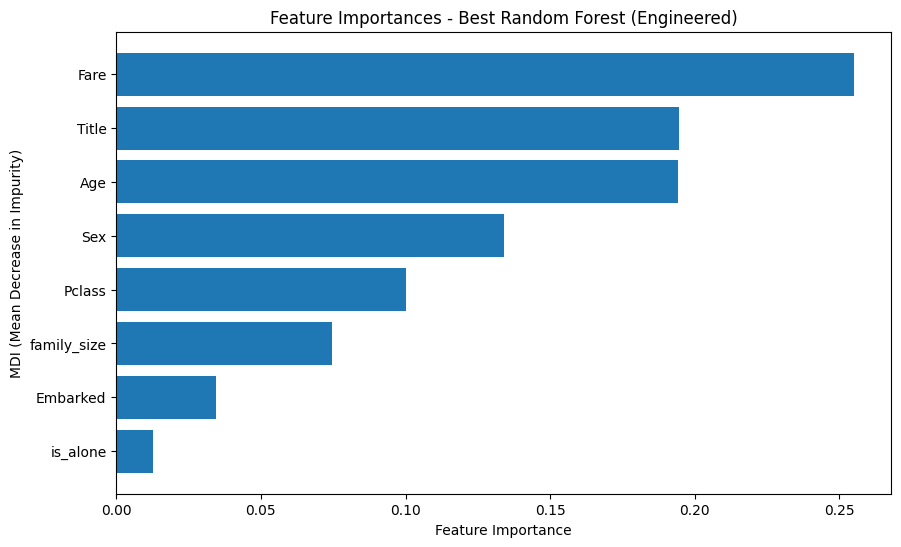

In [102]:
# 1. Pegar as importâncias do melhor modelo (ajuste o nome da variável se necessário)
# Usando o X_train ou DataFrame que contém as colunas novas (Title, family_size, etc.)
importances = pd.Series(model_forest_final.feature_importances_, index=X_train_final.columns)

# 2. Ordenar os valores (Do maior para o menor)
importances = importances.sort_values(ascending=False)

# 3. Plotar exatamente com a mesma lógica do primeiro
plt.figure(figsize=(10, 6))

# Usamos importances.index para garantir que o nome da feature bata com a barra!
plt.barh(range(len(importances)), importances, align='center')
plt.yticks(range(len(importances)), importances.index)

plt.gca().invert_yaxis() # Inverte para a mais importante ficar no topo
plt.xlabel('Feature Importance')
plt.title("Feature Importances - Best Random Forest (Engineered)")
plt.ylabel("MDI (Mean Decrease in Impurity)")
plt.show()

### 🏁 5. Final Evaluation: Testing the Model's Generalization

To conclude the study, we submit our final **Random Forest** with engineered features to the **test dataset**. This step is vital to verify the model's ability to generalize its learning to unseen data, moving beyond the training environment.

We will analyze the final performance through the following metrics:
* **Accuracy Score:** The overall percentage of correct survival predictions.
* **Classification Report:** A detailed look at **Precision, Recall, and F1-Score** for both classes (Survivors and Non-Survivors), ensuring our model isn't biased toward the majority class.
* **Confusion Matrix:** A visual breakdown of True Positives, True Negatives, and where the model is still "confused" by the noise in the Titanic's history.

> **Final Reflection:** By comparing these results with our initial baseline, we can quantify the real impact of our **Feature Engineering** and the shift in feature importance (from raw gender to the economic dominance of `Fare`).

In [89]:
Y_pred = model_forest.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, Y_pred):.2%}")

Accuracy: 82.22%


In [90]:
print(classification_report(y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.87      0.83      0.85        54
           1       0.76      0.81      0.78        36

    accuracy                           0.82        90
   macro avg       0.81      0.82      0.82        90
weighted avg       0.82      0.82      0.82        90



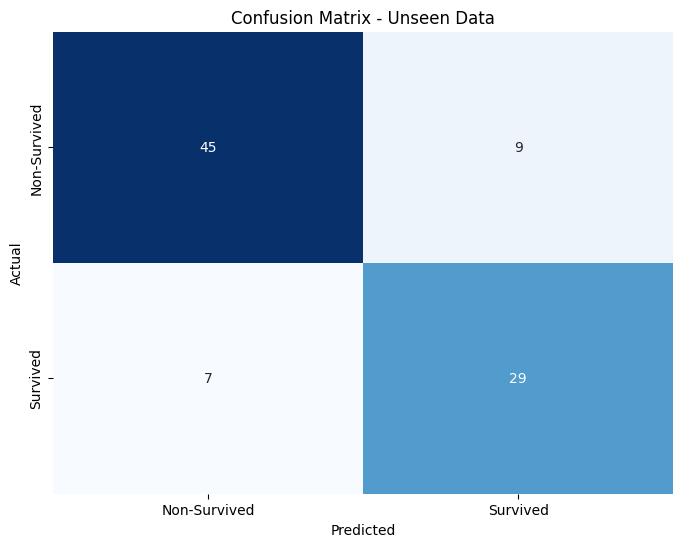

In [103]:
conf_matrix_result = confusion_matrix(y_test, Y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_result, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Survived', 'Survived'], yticklabels=['Non-Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Unseen Data')
plt.show()

### 🏁 6. Final Conclusion: The Predictive Ceiling of the Titanic Dataset

After an extensive journey through data cleaning, advanced **Feature Engineering** (Title, Family Size, IsAlone), and model optimization, we reached a final accuracy of **82.22%** on the unseen test data.

**Key Findings:**

* **The Plateau of Optimization:** One of the most significant insights was observing how even exhaustive techniques like **GridSearchCV** and complex ensemble methods provided only marginal gains over the baseline. This suggests that we reached a "predictive ceiling" inherent to the dataset.
* **Feature Dominance:** The model successfully identified that survival was heavily dictated by socio-economic status (**Fare**) and social context (**Title**), which proved to be more statistically significant than raw biological data like age alone.
* **The Nature of the Data:** The relatively small evolution in metrics, despite significant engineering efforts, reveals the **unpredictable nature** of the Titanic disaster. Real-world events are often governed by "noise" or latent variables (such as cabin location details not present in the data, or simply human chaos and luck) that no algorithm can fully capture.
* **Final Performance:** Achieving **82.22%** accuracy is a robust result for this problem. It demonstrates that while we cannot predict every individual outcome, the Random Forest effectively learned the historical patterns of "Women, Children, and Wealthy first."

This study reinforces a fundamental lesson in Data Science: **Better features usually beat more complex algorithms.** Our focus on understanding the data's context was what ultimately allowed the model to maintain its stability and deliver a high-quality final prediction.